# IEOR 4703 Term Project 1 - VaR, CVaR, and Stress Testing of a Mutual Fund Portfolio

Minhao(Myron) Pang, Siyun(Cheryl) Yan



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from IPython.display import display
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

fmt_dollar = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
fmt_pct    = mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%')

In [ ]:
#  Load price data 
eq_prices   = pd.read_csv('data/us_equity_adj_close.csv',
                          index_col='as_of', parse_dates=True)
bond_prices = pd.read_csv('data/us_bond_intermediate_core_adj_close.csv',
                          index_col='as_of', parse_dates=True)

all_prices = pd.concat([eq_prices, bond_prices], axis=1).sort_index()

STUDY_START = pd.Timestamp('2005-12-31')
STUDY_END   = pd.Timestamp('2024-12-31')
all_prices  = all_prices.loc[STUDY_START:STUDY_END]

#  Step 1: candidate pool — funds with price data from the study start 
early_window   = all_prices.loc['2005-12-31':'2006-01-15']
CANDIDATE_POOL = early_window.columns[early_window.notna().any()].tolist()

#  Step 2: rank candidates by AUM and keep top 50 
# Uses us_equity_fund_size.csv and us_bond_intermediate_fund_size.csv.
# We take the most recent available AUM (in $B) for each fund as the ranking
# criterion. Funds not in the size files (no AUM data) are ranked last.
eq_size   = pd.read_csv('data/us_equity_fund_size.csv')
bond_size = pd.read_csv('data/us_bond_intermediate_fund_size.csv')
all_sizes = pd.concat([eq_size, bond_size], ignore_index=True)

# Most recent AUM per fund
latest_aum = (all_sizes.sort_values('as_of')
                        .groupby('ask_id')['fund_size']
                        .last()
                        .reindex(CANDIDATE_POOL)
                        .fillna(0.0))

FUND_POOL = latest_aum.sort_values(ascending=False).head(50).index.tolist()

#  Monte Carlo price imputation 
# Short gaps (≤ MAX_FFILL days, e.g. weekends/holidays): forward fill.
# Interior gaps (both endpoints known): Brownian Bridge.
# Trailing gaps (no future price known):
#     equity funds: forward GBM (vol-driven random walk)
#     bond funds: duration-carry model with a mean-reverting (Vasicek) yield.
# Equities follow GBM, but bond prices are governed by carry (they accrue their
# yield) and a rate response (ΔP/P ≈ −D·Δy), and yields mean-revert rather than
# random-walk. A plain GBM trailing fill ignores carry and pull-to-par, so we
# route bond columns to a fixed-income-aware model instead.
MAX_FFILL = 5

# Per-bond duration & yield. The duration/yield file is monthly and sparse
# (~17% duration, ~66% YTM, 2000–2020 only), so we collapse it to one stable
# value per bond (median of available obs) with global-median fallbacks.
_dy = pd.read_csv('data/us_bond_intermediate_fixed_income_duration_yield.csv')
BOND_DUR = _dy.groupby('ask_id')['modified_duration'].median()
BOND_YTM = _dy.groupby('ask_id')['yield_to_maturity'].median() / 100.0   # % → decimal
DEFAULT_DUR, DEFAULT_YTM = 4.65, 0.0287   # global medians (fallback)

def _gbm_params(series):
    lr = np.log(series / series.shift(1)).dropna()
    if len(lr) < 20:
        return 0.0, 0.02
    return float(lr.mean()), float(lr.std())

def _gap_bounds(vals):
    """Return (starts, ends) index arrays of each contiguous NaN run."""
    is_nan  = np.isnan(vals)
    changes = np.diff(is_nan.astype(int), prepend=0, append=0)
    starts  = np.where(changes ==  1)[0]
    ends    = np.where(changes == -1)[0] - 1
    return starts, ends

def _brownian_bridge(vals, s, e, sigma, rng):
    """Fill interior gap [s, e] by a Brownian Bridge in log-price."""
    log_a, log_b = np.log(vals[s - 1]), np.log(vals[e + 1])
    m = e - s + 2
    for k, idx in enumerate(range(s, e + 1)):
        t = k + 1
        bb_mean = log_a + (log_b - log_a) * t / m
        bb_std  = sigma * np.sqrt(t * (m - t) / m)
        vals[idx] = np.exp(bb_mean + bb_std * rng.standard_normal())

def impute_prices_mc(prices_series, max_ffill=MAX_FFILL, rng=None):
    """
    Impute missing EQUITY prices with Monte Carlo methods.

    Short gaps  (≤ max_ffill days) : plain forward-fill (holidays/weekends).
    Interior gaps (both endpoints known): Brownian Bridge conditioned on the
        known log-prices at the gap boundaries.
        E[log S_t] = log(S_a) + (log(S_b) - log(S_a)) * t / (n+1)
        Var[log S_t] = σ² * t * (n+1-t) / (n+1)
    Trailing gaps (no future price):   forward GBM simulation.
    Leading NaN (fund not yet started): left as NaN → excluded from pool.
    """
    if rng is None:
        rng = np.random.default_rng(42)
    p = prices_series.ffill(limit=max_ffill)
    if not p.isna().any():
        return p
    mu, sigma = _gbm_params(p.dropna())
    vals = p.to_numpy(dtype=float).copy()
    n    = len(vals)
    starts, ends = _gap_bounds(vals)
    for s, e in zip(starts, ends):
        has_L = s > 0     and not np.isnan(vals[s - 1])
        has_R = e < n - 1 and not np.isnan(vals[e + 1])
        if has_L and has_R:                        # Brownian Bridge
            _brownian_bridge(vals, s, e, sigma, rng)
        elif has_L:                                # Forward GBM
            S = vals[s - 1]
            for idx in range(s, e + 1):
                S = S * np.exp((mu - 0.5*sigma**2) + sigma*rng.standard_normal())
                vals[idx] = S
    return pd.Series(vals, index=prices_series.index, name=prices_series.name)

def impute_bond_prices_mc(prices_series, fid, max_ffill=MAX_FFILL, rng=None,
                          kappa=0.02):
    """
    Impute missing BOND prices.

    Short / interior gaps: identical to equities (forward-fill, Brownian Bridge —
        a bridge is well-anchored at both ends and valid for any asset).
    Trailing gaps (no future price): duration-carry model. The yield follows a
        mean-reverting (Vasicek) process and the daily price return is
            ΔP/P ≈ y/252  −  D_mod · Δy        (carry minus rate move).
        θ      = bond's long-run yield (its median YTM) → pull-to-par
        σ_y    ≈ σ_price / D_mod                → yield vol implied from price vol
        κ      = daily mean-reversion speed
    """
    if rng is None:
        rng = np.random.default_rng(42)
    p = prices_series.ffill(limit=max_ffill)
    if not p.isna().any():
        return p
    _, sigma = _gbm_params(p.dropna())                 # bond's own daily price vol
    D     = BOND_DUR.get(fid, DEFAULT_DUR) or DEFAULT_DUR
    theta = BOND_YTM.get(fid, DEFAULT_YTM) or DEFAULT_YTM
    sig_y = sigma / max(D, 0.5)                         # implied yield vol
    vals = p.to_numpy(dtype=float).copy()
    n    = len(vals)
    starts, ends = _gap_bounds(vals)
    for s, e in zip(starts, ends):
        has_L = s > 0     and not np.isnan(vals[s - 1])
        has_R = e < n - 1 and not np.isnan(vals[e + 1])
        if has_L and has_R:                            # Brownian Bridge
            _brownian_bridge(vals, s, e, sigma, rng)
        elif has_L:                                    # Duration-carry + Vasicek yield
            S, y = vals[s - 1], theta
            for idx in range(s, e + 1):
                dy  = kappa * (theta - y) + sig_y * rng.standard_normal()
                ret = y / 252.0 - D * dy               # carry minus rate move
                y  += dy
                S  *= (1.0 + ret)
                vals[idx] = S
    return pd.Series(vals, index=prices_series.index, name=prices_series.name)

print('Imputing missing prices (equity → GBM/bridge, bond → duration-carry)')
bond_cols  = set(bond_prices.columns)
rng_impute = np.random.default_rng(0)
all_prices = all_prices.apply(
    lambda col: impute_bond_prices_mc(col, col.name, rng=rng_impute)
                if col.name in bond_cols
                else impute_prices_mc(col, rng=rng_impute)
)

#  Metadata 
eq_meta   = pd.read_csv('data/us_equity_intermediate_meta_data.csv',
                        index_col='ask_id')[['sec_name', 'ticker']]
bond_meta = pd.read_csv('data/us_bond_intermediate_meta_data.csv',
                        index_col='ask_id')[['sec_name', 'ticker']]
metadata  = pd.concat([eq_meta, bond_meta])

print(f'\nStudy period  : {STUDY_START.date()}  →  {STUDY_END.date()}')
print(f'Trading days  : {len(all_prices):,}')
print(f'Candidate pool: {len(CANDIDATE_POOL)} funds with data from study start')
print(f'Final pool    : top {len(FUND_POOL)} by AUM (assets under management)')
print(f'\nTop 10 by AUM:')
for fid in FUND_POOL[:10]:
    name = metadata.loc[fid, 'sec_name'] if fid in metadata.index else fid
    aum  = latest_aum.loc[fid]
    ftype = 'equity' if fid in eq_prices.columns else 'bond'
    print(f'  {fid}  {aum:>8.1f} $B  [{ftype:6s}]  {name}')
print(f'\nRemaining NaN in fund pool: {all_prices[FUND_POOL].isna().sum().sum()}')

Imputing missing prices (equity → GBM/bridge, bond → duration-carry)

Study period  : 2005-12-31  →  2024-12-31
Trading days  : 6,941
Candidate pool: 80 funds with data from study start
Final pool    : top 50 by AUM (assets under management)

Top 10 by AUM:
  B02943  152256.0 $B  [equity]  American Funds Fundamental Invs A
  B08417   68962.3 $B  [equity]  Fidelity® Growth Company
  B08639   64633.6 $B  [bond  ]  Fidelity® US Bond Index
  B24012   45080.0 $B  [bond  ]  Vanguard Interm-Term Bond Index Inv
  B08466   23147.8 $B  [equity]  Fidelity® Low-Priced Stock
  B01860    9558.6 $B  [bond  ]  BBH Limited Duration I
  B23689    9545.5 $B  [equity]  Undiscovered Managers Behavioral Val L
  B19389    9273.8 $B  [equity]  Pioneer A
  B18804    8753.5 $B  [equity]  PGIM Jennison Growth A
  B13582    8510.7 $B  [equity]  JHancock Multimanager Lifestyle Gr 1

Remaining NaN in fund pool: 0


---
## Step 1 — User-Defined Parameters

| Parameter | Description | Options |
|-----------|-------------|---------|
| `ts` | Start date (after 2005-12-31) | any trading date |
| `te` | End date (≤ 2024-12-31) | any trading date |
| `d` | Number of mutual funds | 1 – 50 |
| `delta` (δ) | Rolling step | 1=daily, 5=weekly, 22=monthly, 66=quarterly |
| `tau` (τ) | Horizon in trading days | 252≈1yr, 756≈3yr, 1260≈5yr |
| `alpha` (α) | Confidence level | 0.90, 0.95, 0.99 |
| `selected_funds` | Specific fund IDs, or `None` for random | list or None |

**Edit the cell below, then run all cells.**

In [4]:
# ════════════════════════════════════════════════════════════════════
#  USER-DEFINED PARAMETERS  — edit here
# ════════════════════════════════════════════════════════════════════

ts    = '2006-01-03'   # start date  (must be after 2005-12-31)
te    = '2024-12-31'   # end date    (must be ≤ 2024-12-31)

# d is the portfolio size for the MAIN analysis (Step 2 & 3).
# Step 4a automatically sweeps d from 1 → 50 regardless of what you set here.
# Set any value from 1 to len(FUND_POOL) as your baseline.
d     = 10             # baseline number of mutual funds

delta = 22             # rolling step δ:  1=daily | 5=weekly | 22=monthly | 66=quarterly
tau   = 252            # investment horizon τ in trading days (252≈1yr, 756≈3yr, 1260≈5yr)
alpha = 0.95           # confidence level α

N_SIM         = 10_000     # bootstrap simulation draws
INITIAL_VALUE = 1_000_000  # total portfolio value ($)

# Fund selection: None = randomly pick d funds, or provide a list e.g. ['B13779', 'B14678']
selected_funds = None

# ════════════════════════════════════════════════════════════════════

# Validation
assert pd.Timestamp(ts) > STUDY_START,  f'ts must be after {STUDY_START.date()}'
assert pd.Timestamp(te) <= STUDY_END,   f'te must be ≤ {STUDY_END.date()}'
assert 1 <= d <= len(FUND_POOL),        f'd must be 1–{len(FUND_POOL)}'
assert delta in (1, 5, 22, 66),         'delta must be 1, 5, 22, or 66'
assert 0 < alpha < 1,                   'alpha must be in (0, 1)'

DELTA_LABEL = {1: 'daily', 5: 'weekly', 22: 'monthly', 66: 'quarterly'}[delta]

# Fund selection
if selected_funds is None:
    rng = np.random.default_rng(42)
    selected_funds = list(rng.choice(FUND_POOL, size=d, replace=False))
else:
    assert len(selected_funds) == d
    assert all(f in FUND_POOL for f in selected_funds)

print(f'Portfolio configuration')
print(f'  Date range   : {ts}  →  {te}')
print(f'  Horizon τ    : {tau} trading days  ({tau/252:.1f} years)')
print(f'  Roll step δ  : {delta}  ({DELTA_LABEL})')
print(f'  Confidence α : {alpha*100:.0f}%')
print(f'  Funds d      : {d}  (Step 4a will sweep 1 → {min(len(FUND_POOL), 50)})')
print()
print('Selected funds:')
for fid in selected_funds:
    name = metadata.loc[fid, 'sec_name'] if fid in metadata.index else fid
    tick = metadata.loc[fid, 'ticker']   if fid in metadata.index else ''
    print(f'  {fid}  {tick:<8}  {name}')

Portfolio configuration
  Date range   : 2006-01-03  →  2024-12-31
  Horizon τ    : 252 trading days  (1.0 years)
  Roll step δ  : 22  (monthly)
  Confidence α : 95%
  Funds d      : 10  (Step 4a will sweep 1 → 50)

Selected funds:
  B08466  FLPSX     Fidelity® Low-Priced Stock
  B18227  FCBYX     Nuveen Strategic Income I
  B24012  VBIIX     Vanguard Interm-Term Bond Index Inv
  B13779  nan       JNL/DFA US Core Equity A
  B07369  QILGX     Federated Hermes MDT Large Cap Growth IS
  B06127  FICGX     Delaware Growth Equity A
  B14031  JFINX     Johnson Fixed-Income
  B03784  ADCIX     American Century Disciplined Growth I
  B13582  JILGX     JHancock Multimanager Lifestyle Gr 1
  B14562  JPDEX     JPMorgan Tax Aware Equity I


---
## Step 2 — Historical Return Distribution

For fund $i$, the τ-horizon return starting at trading day $t$ (0-indexed):
$$r_{t,\tau}^{(i)} = \frac{p_{t+\tau}^{(i)} - p_t^{(i)}}{p_t^{(i)}}$$

Rolling with step δ, the sampled series is $\{r_{j\delta,\,\tau}^{(i)}\}_{j=0,\ldots,L-1}$ where $L = \lfloor(N - \tau)/\delta\rfloor$ and $N$ is the number of trading days in $[t_s, t_e]$.

The equal-weight portfolio return at each step is $r_j^{\text{port}} = \frac{1}{d}\sum_{i=1}^{d} r_{j\delta,\tau}^{(i)}$.

In [5]:
def build_rolling_returns(prices_df, fund_ids, ts, te, tau, delta):
    """
    Build rolling τ-horizon returns for an equal-weight portfolio.

    Returns
    -------
    fund_returns      : ndarray (L, d)  – individual fund τ-horizon returns
    portfolio_returns : ndarray (L,)    – equal-weight portfolio returns
    start_dates       : DatetimeIndex   – calendar date of each window start
    L                 : int             – number of observations
    """
    p = prices_df.loc[pd.Timestamp(ts):pd.Timestamp(te), fund_ids].copy()
    p = p.ffill()   # forward-fill intra-series gaps (holidays, etc.)

    N          = len(p)
    prices_arr = p.to_numpy(dtype=float)

    # Rolling start indices (0-based): 0, δ, 2δ, … up to N-τ-1
    start_idx = np.arange(0, N - tau, delta)
    end_idx   = start_idx + tau
    L         = len(start_idx)

    p0 = prices_arr[start_idx]      # prices at window start  shape (L, d)
    pt = prices_arr[end_idx]        # prices at window end    shape (L, d)
    fund_returns      = (pt - p0) / p0
    portfolio_returns = np.nanmean(fund_returns, axis=1)

    return fund_returns, portfolio_returns, p.index[start_idx], L


print('Building rolling return distributions …')
fund_returns, portfolio_returns, start_dates, L = build_rolling_returns(
    all_prices, selected_funds, ts, te, tau, delta
)

ret_series = pd.Series(portfolio_returns, index=start_dates, name='Portfolio Return')

print(f'\nHistorical return distribution')
print(f'  Observations L   : {L}')
print(f'  Mean             : {portfolio_returns.mean()*100:+.2f}%')
print(f'  Std dev          : {portfolio_returns.std()*100:.2f}%')
print(f'  Min              : {portfolio_returns.min()*100:+.2f}%')
print(f'  Max              : {portfolio_returns.max()*100:+.2f}%')
print(f'  Skewness         : {pd.Series(portfolio_returns).skew():.4f}')
print(f'  Excess kurtosis  : {pd.Series(portfolio_returns).kurtosis():.4f}')

Building rolling return distributions …

Historical return distribution
  Observations L   : 304
  Mean             : +6.30%
  Std dev          : 10.80%
  Min              : -32.64%
  Max              : +49.36%
  Skewness         : -0.6480
  Excess kurtosis  : 2.2733


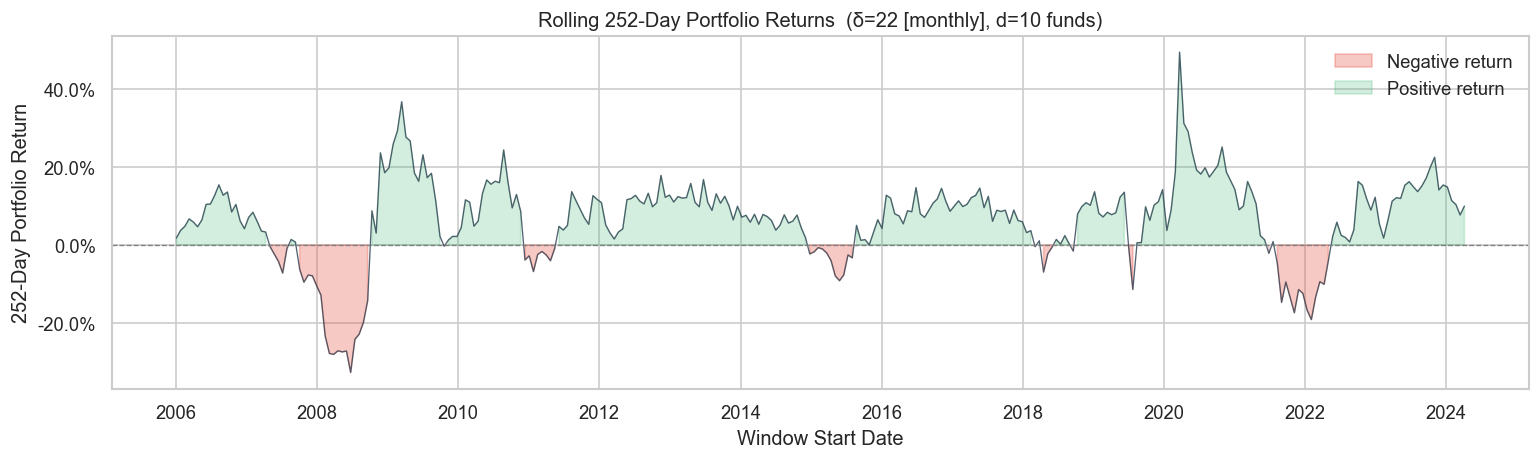

In [6]:
# Time series of rolling portfolio returns
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ret_series.index, ret_series.values, linewidth=0.8, color='#2c3e50', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between(ret_series.index, ret_series.values, 0,
                where=ret_series.values < 0, color='#e74c3c', alpha=0.3, label='Negative return')
ax.fill_between(ret_series.index, ret_series.values, 0,
                where=ret_series.values >= 0, color='#27ae60', alpha=0.2, label='Positive return')
ax.yaxis.set_major_formatter(fmt_pct)
ax.set_xlabel('Window Start Date')
ax.set_ylabel(f'{tau}-Day Portfolio Return')
ax.set_title(f'Rolling {tau}-Day Portfolio Returns  (δ={delta} [{DELTA_LABEL}], d={d} funds)')
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

---
## Step 3 — VaR and CVaR via Bootstrap Simulation

Draw $N_{\text{sim}}$ returns with replacement from the empirical distribution $\{r_j^{\text{port}}\}$:

$$\text{VaR}_\alpha = -Q_{1-\alpha}(r^{\text{sim}}) \times V_0$$
$$\text{CVaR}_\alpha = -\mathbb{E}\!\left[r^{\text{sim}} \mid r^{\text{sim}} \leq Q_{1-\alpha}(r^{\text{sim}})\right] \times V_0$$

> **Does annualisation matter?** VaR and CVaR are horizon-specific dollar-loss measures. Working directly with τ-horizon returns gives the correct risk over that horizon. Annualising the returns rescales them but preserves the relative ordering, so the **dollar VaR and CVaR are unaffected** by annualisation as long as you are consistent. For cross-horizon comparisons it is more natural to keep returns at the native τ scale.

In [7]:
def compute_var_cvar(portfolio_returns, alpha, n_sim, initial_value, seed=0):
    """
    Bootstrap simulation of VaR and CVaR.

    Parameters
    ----------
    portfolio_returns : 1-D array of τ-horizon portfolio returns
    alpha            : confidence level (e.g. 0.95)
    n_sim            : number of bootstrap draws
    initial_value    : portfolio value in dollars
    seed             : random seed

    Returns
    -------
    dict with VaR, CVaR (dollar losses, positive = bad), return quantiles,
    and the full simulated return array.
    """
    rng = np.random.default_rng(seed)
    sim = rng.choice(portfolio_returns, size=n_sim, replace=True)

    q           = np.percentile(sim, (1 - alpha) * 100)   # (1-α)-quantile of returns
    var_dollar  = -q * initial_value
    tail_mean   = sim[sim <= q].mean()
    cvar_dollar = -tail_mean * initial_value

    return {
        'VaR':         var_dollar,
        'CVaR':        cvar_dollar,
        'VaR_return':  q,
        'CVaR_return': tail_mean,
        'sim':         sim,
    }


print(f'Running {N_SIM:,} bootstrap simulations …')
results = compute_var_cvar(portfolio_returns, alpha, N_SIM, INITIAL_VALUE)

print()
print('='*52)
print('  PORTFOLIO RISK METRICS')
print('='*52)
print(f'  Investment       : ${INITIAL_VALUE:>12,.0f}')
print(f'  Horizon τ        : {tau} trading days  ({tau/252:.1f} yr)')
print(f'  Rolling step δ   : {delta}  ({DELTA_LABEL})')
print(f'  Confidence α     : {alpha*100:.0f}%')
print(f'  Funds d          : {d}')
print(f'  Observations L   : {L}')
print('='*52)
print(f'  VaR  ({alpha*100:.0f}%)       : ${results["VaR"]:>12,.2f}  '
      f'({-results["VaR_return"]*100:.2f}% loss)')
print(f'  CVaR ({alpha*100:.0f}%)       : ${results["CVaR"]:>12,.2f}  '
      f'({-results["CVaR_return"]*100:.2f}% loss)')
print('='*52)

Running 10,000 bootstrap simulations …

  PORTFOLIO RISK METRICS
  Investment       : $   1,000,000
  Horizon τ        : 252 trading days  (1.0 yr)
  Rolling step δ   : 22  (monthly)
  Confidence α     : 95%
  Funds d          : 10
  Observations L   : 304
  VaR  (95%)       : $  133,856.46  (13.39% loss)
  CVaR (95%)       : $  223,450.13  (22.35% loss)


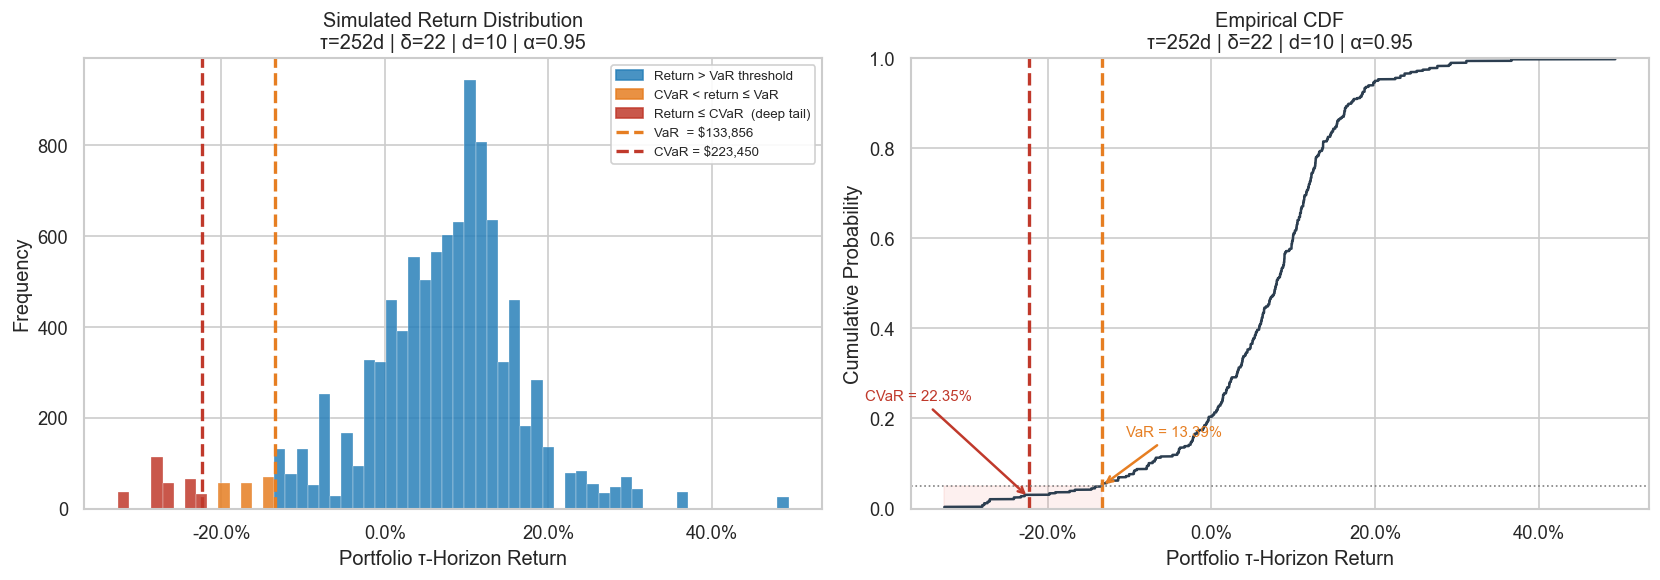

In [8]:
# Return distribution histogram + empirical CDF
sim   = results['sim']
var_r = results['VaR_return']
cvar_r = results['CVaR_return']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: colour-coded histogram
bins = 60
n, edges = np.histogram(sim, bins=bins)
centers  = (edges[:-1] + edges[1:]) / 2
width    = edges[1] - edges[0]
colors   = np.where(centers <= cvar_r, '#c0392b',
           np.where(centers <= var_r,  '#e67e22', '#2980b9'))
ax1.bar(centers, n, width=width, color=colors, alpha=0.85, edgecolor='white', linewidth=0.2)
ax1.axvline(var_r,  color='#e67e22', linewidth=2, linestyle='--')
ax1.axvline(cvar_r, color='#c0392b', linewidth=2, linestyle='--')
patches = [
    mpatches.Patch(color='#2980b9', alpha=0.85, label='Return > VaR threshold'),
    mpatches.Patch(color='#e67e22', alpha=0.85, label='CVaR < return ≤ VaR'),
    mpatches.Patch(color='#c0392b', alpha=0.85, label='Return ≤ CVaR  (deep tail)'),
    plt.Line2D([0],[0], color='#e67e22', lw=2, ls='--', label=f'VaR  = ${results["VaR"]:,.0f}'),
    plt.Line2D([0],[0], color='#c0392b', lw=2, ls='--', label=f'CVaR = ${results["CVaR"]:,.0f}'),
]
ax1.legend(handles=patches, fontsize=8, framealpha=0.9)
ax1.xaxis.set_major_formatter(fmt_pct)
ax1.set_xlabel('Portfolio τ-Horizon Return')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Simulated Return Distribution\nτ={tau}d | δ={delta} | d={d} | α={alpha}')

# Right: empirical CDF
sorted_r = np.sort(sim)
cdf      = np.linspace(1/N_SIM, 1, N_SIM)
ax2.plot(sorted_r, cdf, color='#2c3e50', linewidth=1.5)
ax2.axvline(var_r,  color='#e67e22', linewidth=2, linestyle='--')
ax2.axvline(cvar_r, color='#c0392b', linewidth=2, linestyle='--')
ax2.axhline(1-alpha, color='gray', linewidth=1, linestyle=':')
ax2.fill_betweenx([0, 1-alpha], sorted_r.min(), var_r, alpha=0.08, color='#e74c3c')
y_ann = max(0.04, 1 - alpha - 0.05)
ax2.annotate(f'VaR = {-var_r*100:.2f}%',
             xy=(var_r, 1-alpha), xytext=(var_r + 0.03, y_ann + 0.12),
             arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5),
             color='#e67e22', fontsize=9)
ax2.annotate(f'CVaR = {-cvar_r*100:.2f}%',
             xy=(cvar_r, (1-alpha)/2), xytext=(cvar_r - 0.20, y_ann + 0.20),
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
             color='#c0392b', fontsize=9)
ax2.xaxis.set_major_formatter(fmt_pct)
ax2.set_xlabel('Portfolio τ-Horizon Return')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title(f'Empirical CDF\nτ={tau}d | δ={delta} | d={d} | α={alpha}')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## Step 4 — Sensitivity Analysis

How do VaR and CVaR change as we independently vary **d** (fund count), **δ** (rolling step), and **τ** (horizon)?

Sweeping d …


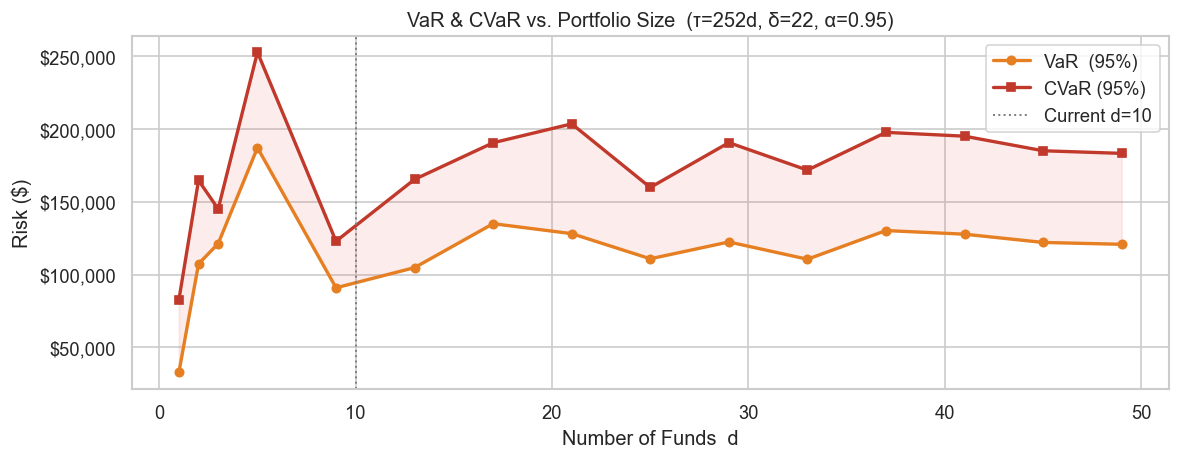

In [9]:
# 4a  VaR & CVaR vs. number of funds d
rng_sweep = np.random.default_rng(0)
max_d     = min(len(FUND_POOL), 50)
d_values  = sorted(set([1, 2, 3, 5] + list(range(5, max_d + 1, max(1, max_d // 12)))))

vars_d, cvars_d = [], []
print('Sweeping d …')
for d_val in d_values:
    funds_sel = list(rng_sweep.choice(FUND_POOL, size=d_val, replace=False))
    _, pr, _, _ = build_rolling_returns(all_prices, funds_sel, ts, te, tau, delta)
    res = compute_var_cvar(pr, alpha, N_SIM, INITIAL_VALUE, seed=d_val)
    vars_d.append(res['VaR'])
    cvars_d.append(res['CVaR'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d_values, vars_d,  'o-', color='#e67e22', lw=2, ms=5, label=f'VaR  ({alpha*100:.0f}%)')
ax.plot(d_values, cvars_d, 's-', color='#c0392b', lw=2, ms=5, label=f'CVaR ({alpha*100:.0f}%)')
ax.fill_between(d_values, vars_d, cvars_d, alpha=0.10, color='#e74c3c')
ax.axvline(d, color='gray', linewidth=1.2, linestyle=':', label=f'Current d={d}')
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_xlabel('Number of Funds  d')
ax.set_ylabel('Risk ($)')
ax.set_title(f'VaR & CVaR vs. Portfolio Size  (τ={tau}d, δ={delta}, α={alpha})')
ax.legend()
plt.tight_layout()
plt.show()

Sweeping δ …


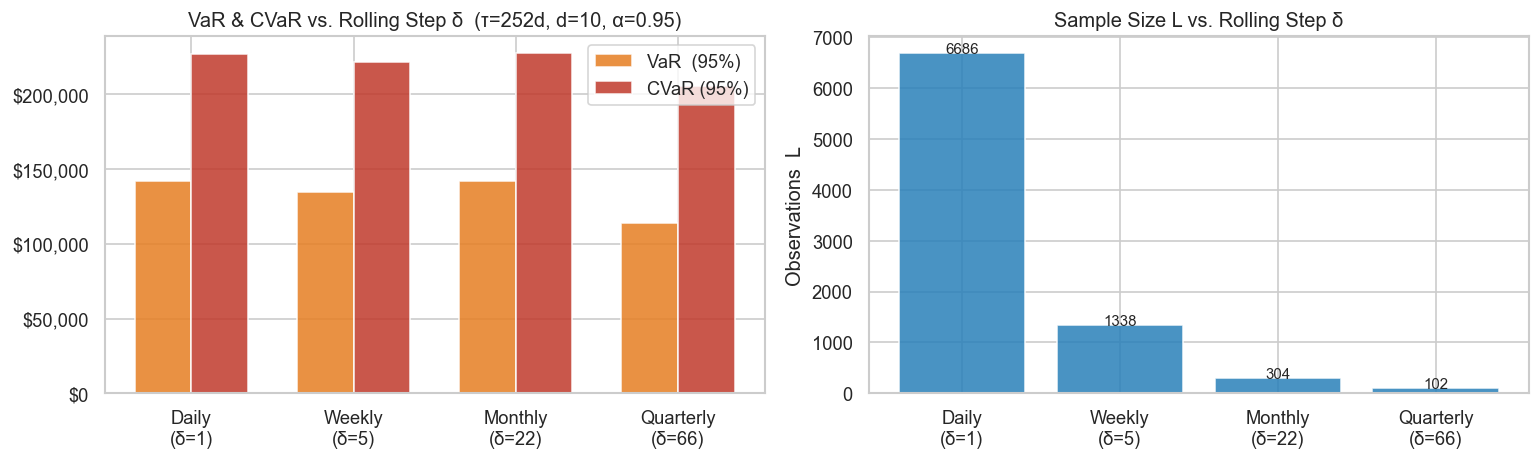

In [10]:
# 4b  VaR & CVaR vs. rolling step δ
delta_sweep  = [1, 5, 22, 66]
delta_labels = ['Daily\n(δ=1)', 'Weekly\n(δ=5)', 'Monthly\n(δ=22)', 'Quarterly\n(δ=66)']

vars_delta, cvars_delta, L_vals = [], [], []
print('Sweeping δ …')
for dlt in delta_sweep:
    _, pr, _, L_v = build_rolling_returns(all_prices, selected_funds, ts, te, tau, dlt)
    res = compute_var_cvar(pr, alpha, N_SIM, INITIAL_VALUE, seed=dlt)
    vars_delta.append(res['VaR'])
    cvars_delta.append(res['CVaR'])
    L_vals.append(L_v)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
x, w = np.arange(4), 0.35
ax1.bar(x - w/2, vars_delta,  w, color='#e67e22', alpha=0.85, label=f'VaR  ({alpha*100:.0f}%)')
ax1.bar(x + w/2, cvars_delta, w, color='#c0392b', alpha=0.85, label=f'CVaR ({alpha*100:.0f}%)')
ax1.set_xticks(x); ax1.set_xticklabels(delta_labels)
ax1.yaxis.set_major_formatter(fmt_dollar)
ax1.set_title(f'VaR & CVaR vs. Rolling Step δ  (τ={tau}d, d={d}, α={alpha})')
ax1.legend()

ax2.bar(delta_labels, L_vals, color='#2980b9', alpha=0.85)
for i, v in enumerate(L_vals):
    ax2.text(i, v + 2, str(v), ha='center', fontsize=9)
ax2.set_ylabel('Observations  L')
ax2.set_title('Sample Size L vs. Rolling Step δ')

plt.tight_layout()
plt.show()

Sweeping τ …


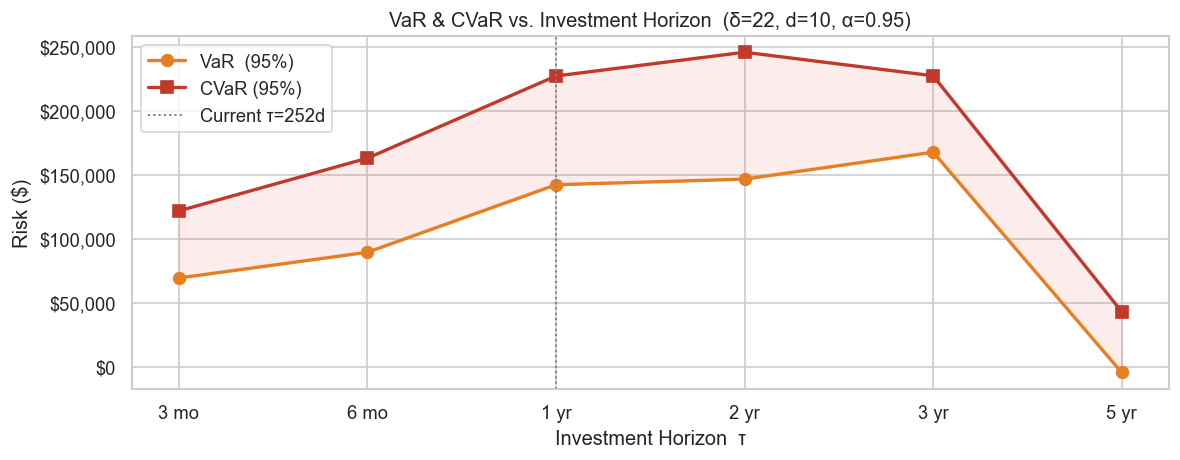

In [11]:
# 4c  VaR & CVaR vs. investment horizon τ
tau_sweep  = [63, 126, 252, 504, 756, 1260]
tau_labels = ['3 mo', '6 mo', '1 yr', '2 yr', '3 yr', '5 yr']

vars_tau, cvars_tau = [], []
print('Sweeping τ …')
for t_val in tau_sweep:
    _, pr, _, L_v = build_rolling_returns(all_prices, selected_funds, ts, te, t_val, delta)
    if L_v < 5:
        vars_tau.append(np.nan); cvars_tau.append(np.nan); continue
    res = compute_var_cvar(pr, alpha, N_SIM, INITIAL_VALUE, seed=t_val)
    vars_tau.append(res['VaR'])
    cvars_tau.append(res['CVaR'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tau_labels, vars_tau,  'o-', color='#e67e22', lw=2, ms=7, label=f'VaR  ({alpha*100:.0f}%)')
ax.plot(tau_labels, cvars_tau, 's-', color='#c0392b', lw=2, ms=7, label=f'CVaR ({alpha*100:.0f}%)')
ax.fill_between(tau_labels, vars_tau, cvars_tau, alpha=0.10, color='#e74c3c')
if tau in tau_sweep:
    ax.axvline(tau_labels[tau_sweep.index(tau)], color='gray', lw=1.2, ls=':', label=f'Current τ={tau}d')
ax.yaxis.set_major_formatter(fmt_dollar)
ax.set_xlabel('Investment Horizon  τ')
ax.set_ylabel('Risk ($)')
ax.set_title(f'VaR & CVaR vs. Investment Horizon  (δ={delta}, d={d}, α={alpha})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 5 — Stress Testing

### How it works

We use **four holding files** to translate macro shocks into fund-level return impacts:

| File | Used for |
|------|----------|
| `us_equity_sectors.csv` | Equity sector shocks (tech crash, energy) |
| `us_bond_intermediate_fixed_income_primary_sector.csv` | Bond sector shocks (corp credit, govt) |
| `us_bond_intermediate_fixed_income_duration_yield.csv` | Rate shocks via **modified duration**: $\Delta P/P \approx -D_{\text{mod}} \times \Delta r$ |
| `us_bond_intermediate_core_credit_quality.csv` | Credit spread shocks weighted by rating bucket |
| `us_equity_economic_region_exposure.csv` | Geographic shocks (EM crisis, Europe recession) |

### Shock mechanism

For each fund $i$ and scenario, the total return shock is:
$$\text{shock}_i = \underbrace{\sum_s \frac{w_{i,s}}{100}\,\sigma_s}_{\text{sector/region}} \;+\; \underbrace{(-D_{\text{mod},i} \times \Delta r)}_{\text{rate risk}} \;+\; \underbrace{\sum_g \frac{w_{i,g}}{100}\,\sigma_g^{\text{credit}}}_{\text{credit risk}}$$

The stressed historical return for each rolling window $j$ becomes:
$$r_{j,\text{stressed}}^{(i)} = r_j^{(i)} + \text{shock}_i$$

VaR and CVaR are then **recomputed by bootstrapping from the shifted distribution**. The stress test does not change the *shape* of the distribution — it shifts the whole distribution left, increasing both VaR and CVaR.

In [12]:
# ── Load all holdings files ───────────────────────────────────────────────────
eq_sectors   = pd.read_csv('data/us_equity_sectors.csv')
bond_sectors = pd.read_csv('data/us_bond_intermediate_fixed_income_primary_sector.csv')
bond_dur     = pd.read_csv('data/us_bond_intermediate_fixed_income_duration_yield.csv')
bond_credit  = pd.read_csv('data/us_bond_intermediate_core_credit_quality.csv')
eq_region    = pd.read_csv('data/us_equity_economic_region_exposure.csv')

EQ_SEC_COLS    = [c for c in eq_sectors.columns   if c.startswith('equity_econ_sector')]
BOND_SEC_COLS  = [c for c in bond_sectors.columns if c.startswith('fixed_inc_ps')]
CREDIT_COLS    = [c for c in bond_credit.columns  if c.startswith('credit_qual')]
REGION_COLS    = [c for c in eq_region.columns    if c.startswith('equity_region')]

def latest_row(df, fund_ids, value_cols, id_col='ask_id', date_col='as_of'):
    """Return a DataFrame (funds × value_cols) with the most recent row per fund."""
    rows = []
    for fid in fund_ids:
        sub = df[df[id_col] == fid].sort_values(date_col)
        row = (sub.iloc[-1][value_cols].fillna(0.0)
               if not sub.empty
               else pd.Series(0.0, index=value_cols))
        rows.append(row.rename(fid))
    return pd.DataFrame(rows).astype(float)

eq_funds   = [f for f in selected_funds if f in eq_sectors['ask_id'].values]
bond_funds = [f for f in selected_funds if f in bond_sectors['ask_id'].values]

eq_w      = latest_row(eq_sectors,  eq_funds,   EQ_SEC_COLS)
bond_w    = latest_row(bond_sectors, bond_funds, BOND_SEC_COLS)
credit_w  = latest_row(bond_credit,  bond_funds, CREDIT_COLS)
region_w  = latest_row(eq_region,    eq_funds,   REGION_COLS)

# Modified duration: scalar per bond fund (most recent, in years)
dur_df  = bond_dur.sort_values('as_of').dropna(subset=['modified_duration'])
mod_dur = (dur_df.groupby('ask_id')['modified_duration']
                  .last()
                  .reindex(bond_funds)
                  .fillna(0.0))

print(f'Equity funds with sector data     : {len(eq_funds)}')
print(f'Bond funds with sector data       : {len(bond_funds)}')
print(f'Bond funds with duration data     : {(mod_dur > 0).sum()}')
print(f'Bond funds with credit-quality    : {len(credit_w)}')
print(f'Equity funds with region exposure : {len(region_w)}')

print('\nModified duration (years) for bond funds in portfolio:')
for fid in bond_funds:
    if fid in mod_dur.index and mod_dur[fid] > 0:
        name = metadata.loc[fid, 'sec_name'] if fid in metadata.index else fid
        print(f'  {fid}  dur={mod_dur[fid]:.2f}y   {name}')

print('\nMean equity sector weights (%):')
if not eq_w.empty:
    display(eq_w.mean()
               .rename(lambda c: c.replace('equity_econ_sector_','').replace('_pct_net',''))
               .sort_values(ascending=False).round(1)
               .to_frame('mean %').T)

print('\nMean bond sector weights (%):')
if not bond_w.empty:
    display(bond_w.mean()
                  .rename(lambda c: c.replace('fixed_inc_ps_','').replace('_pct_net',''))
                  .sort_values(ascending=False).round(1)
                  .to_frame('mean %').T)

Equity funds with sector data     : 7
Bond funds with sector data       : 3
Bond funds with duration data     : 2
Bond funds with credit-quality    : 3
Equity funds with region exposure : 7

Modified duration (years) for bond funds in portfolio:
  B24012  dur=5.90y   Vanguard Interm-Term Bond Index Inv
  B14031  dur=6.04y   Johnson Fixed-Income

Mean equity sector weights (%):


,technology,consumer_cyclical,healthcare,financial_services,communication_services,industrials,consumer_defensive,basic_materials,energy,utilities,real_est
mean %,26.5,15.8,14.2,10.8,8.5,8.2,5.9,1.7,1.4,1.3,1.1



Mean bond sector weights (%):


,corporate_bond,gov,ag_mtge_bck,asset_bck,convertible,bank_loan,gov_related,commercial_mtge_bck,cash_and_equivalents,municipal_taxable,non_ag_res_mtge_bck,preferred_stock,option_warrant,forward_future,municipal_tax_exempt,covered_bond,swap
mean %,46.7,24.6,9.8,3.8,2.9,2.7,2.5,2.3,1.7,1.6,0.8,0.5,0.0,0.0,0.0,0.0,0.0


In [14]:
def compute_fund_shocks(fund_ids,
                        eq_w, bond_w, credit_w, region_w, mod_dur,
                        eq_sec_shocks  = None,
                        bond_sec_shocks= None,
                        rate_shock_bps = 0.0,
                        credit_shocks  = None,
                        region_shocks  = None):
    """
    Compute a per-fund additive return shock from four sources.

    Parameters
    ----------
    eq_sec_shocks   : dict {equity_sector_col: shock_fraction}
    bond_sec_shocks : dict {bond_sector_col:   shock_fraction}
    rate_shock_bps  : parallel rate shift in basis points (+ = rates rise)
                      Impact on bond fund i: -mod_dur[i] * rate_shock_bps/10000
    credit_shocks   : dict {credit_qual_col: shock_fraction}
                      Applied to bond funds via their rating-bucket weights
    region_shocks   : dict {region_col: shock_fraction}
                      Applied to equity funds via their regional weights

    Returns
    -------
    shocks : dict {fund_id: total_shock_fraction}
    """
    eq_sec_shocks   = eq_sec_shocks   or {}
    bond_sec_shocks = bond_sec_shocks or {}
    credit_shocks   = credit_shocks   or {}
    region_shocks   = region_shocks   or {}
    delta_r = rate_shock_bps / 10_000.0

    shocks = {}
    for fid in fund_ids:
        c = 0.0

        # 1. Equity sector shock
        if fid in eq_w.index:
            for col, s in eq_sec_shocks.items():
                c += (eq_w.loc[fid, col] / 100.0) * s

        # 2. Bond sector shock
        if fid in bond_w.index:
            for col, s in bond_sec_shocks.items():
                c += (bond_w.loc[fid, col] / 100.0) * s

        # 3. Rate shock via modified duration:  ΔP/P ≈ -D_mod × Δr
        if fid in mod_dur.index:
            c += -mod_dur[fid] * delta_r

        # 4. Credit spread shock via rating-bucket weights
        if fid in credit_w.index:
            for col, s in credit_shocks.items():
                c += (credit_w.loc[fid, col] / 100.0) * s

        # 5. Geographic / regional shock
        if fid in region_w.index:
            for col, s in region_shocks.items():
                c += (region_w.loc[fid, col] / 100.0) * s

        shocks[fid] = c
    return shocks


def apply_shocks(fund_returns_arr, fund_ids, shocks):
    """Add per-fund shock scalars to returns and return equal-weight portfolio."""
    stressed = fund_returns_arr.copy()
    for j, fid in enumerate(fund_ids):
        stressed[:, j] += shocks.get(fid, 0.0)
    return np.nanmean(stressed, axis=1)


# ─────────────────────────────────────────────────────────────────────────────
# Stress scenarios
# Each entry: (label, kwargs passed to compute_fund_shocks)
# ─────────────────────────────────────────────────────────────────────────────
SCENARIOS = [
    # ── Equity sector shocks ─────────────────────────────────────────────────
    ('Tech Crash −30%',
     dict(eq_sec_shocks={'equity_econ_sector_technology_pct_net': -0.30})),

    ('Energy Shock −40%',
     dict(eq_sec_shocks={'equity_econ_sector_energy_pct_net': -0.40})),

    # ── Rate shock via modified duration ─────────────────────────────────────
    # Rates rise 200 bps → bond fund i loses  D_mod × 0.02
    ('Rate Spike +200 bps',
     dict(rate_shock_bps=200)),

    # ── Credit spread widening ────────────────────────────────────────────────
    # IG (BBB/A/AA) spreads +300 bps, HY (BB/B/below-B) spreads +600 bps.
    # Approximate price impact using average spread duration ≈ 1 (simplified).
    ('Credit Crisis\nIG +300bps / HY +600bps',
     dict(credit_shocks={
         'credit_qual_aaa_pct':    -0.01,   # minimal AAA impact
         'credit_qual_aa_pct':     -0.02,
         'credit_qual_a_pct':      -0.03,
         'credit_qual_bbb_pct':    -0.05,
         'credit_qual_bb_pct':     -0.08,
         'credit_qual_b_pct':      -0.12,
         'credit_qual_below_b_pct':-0.18,
     })),

    # ── Geographic shock ─────────────────────────────────────────────────────
    ('EM Crisis\nEmerging Markets −25%',
     dict(region_shocks={
         'equity_region_emerging_pct_net':    -0.25,
         'equity_region_asia_emrg_pct_net':   -0.25,
         'equity_region_latin_america_pct_net':-0.25,
         'equity_region_europe_emrg_pct_net': -0.20,
     })),

    # ── Combined: broad financial crisis ─────────────────────────────────────
    ('Broad Crisis\n(all channels)',
     dict(eq_sec_shocks={
              'equity_econ_sector_technology_pct_net':         -0.25,
              'equity_econ_sector_financial_services_pct_net': -0.20,
              'equity_econ_sector_consumer_cyclical_pct_net':  -0.18,
          },
          bond_sec_shocks={
              'fixed_inc_ps_corporate_bond_pct_net': -0.10,
          },
          rate_shock_bps=150,
          credit_shocks={
              'credit_qual_bbb_pct': -0.04,
              'credit_qual_bb_pct':  -0.07,
              'credit_qual_b_pct':   -0.10,
          },
          region_shocks={
              'equity_region_emerging_pct_net': -0.20,
          })),
]

base_var  = results['VaR']
base_cvar = results['CVaR']

stress_results = []
print(f'{"Scenario":<44} {"VaR ($)":>13} {"CVaR ($)":>13} {"ΔVaR ($)":>11} {"ΔCVaR ($)":>11}')
print('-' * 95)
print(f'{"Baseline (no shock)":<44} ${base_var:>12,.0f} ${base_cvar:>12,.0f}')
print('-' * 95)

for label, kwargs in SCENARIOS:
    shocks      = compute_fund_shocks(selected_funds,
                                      eq_w, bond_w, credit_w, region_w, mod_dur,
                                      **kwargs)
    stressed_pr = apply_shocks(fund_returns, selected_funds, shocks)
    s           = compute_var_cvar(stressed_pr, alpha, N_SIM, INITIAL_VALUE)
    dv, dc      = s['VaR'] - base_var, s['CVaR'] - base_cvar
    stress_results.append((label, s['VaR'], s['CVaR'], dv, dc))
    flat = label.replace('\n', ' ')
    print(f'{flat:<44} ${s["VaR"]:>12,.0f} ${s["CVaR"]:>12,.0f} ${dv:>+10,.0f} ${dc:>+10,.0f}')

Scenario                                           VaR ($)      CVaR ($)    ΔVaR ($)   ΔCVaR ($)
-----------------------------------------------------------------------------------------------
Baseline (no shock)                          $     133,856 $     223,450
-----------------------------------------------------------------------------------------------
Tech Crash −30%                              $     189,467 $     279,061 $   +55,611 $   +55,611
Energy Shock −40%                            $     137,904 $     227,498 $    +4,048 $    +4,048
Rate Spike +200 bps                          $     157,736 $     247,330 $   +23,880 $   +23,880
Credit Crisis IG +300bps / HY +600bps        $     144,578 $     234,172 $   +10,722 $   +10,722
EM Crisis Emerging Markets −25%              $     139,081 $     228,675 $    +5,224 $    +5,224
Broad Crisis (all channels)                  $     255,235 $     344,829 $  +121,379 $  +121,379


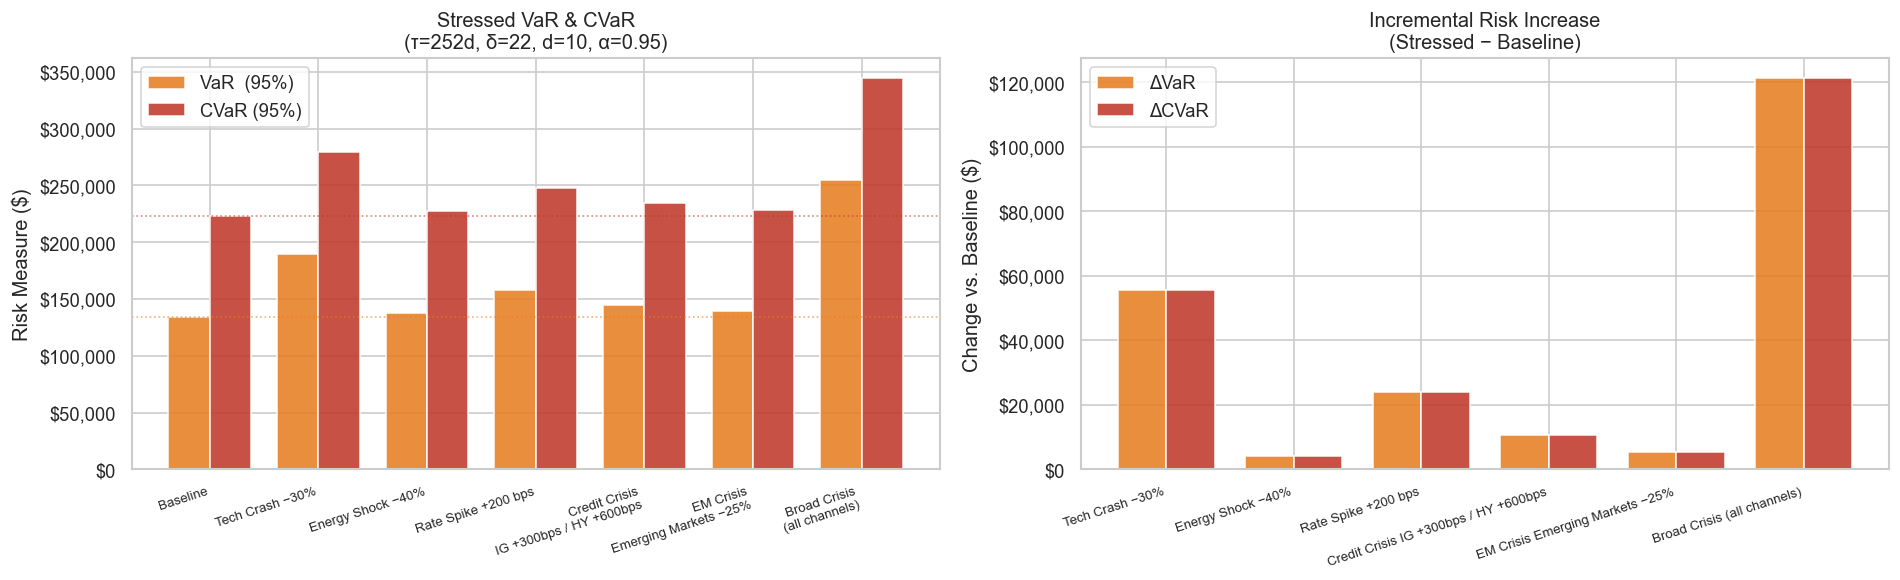

In [15]:
# Stress test visualisation
s_labels = ['Baseline'] + [r[0] for r in stress_results]
all_vars  = [base_var]  + [r[1] for r in stress_results]
all_cvars = [base_cvar] + [r[2] for r in stress_results]
n_scen = len(s_labels)
x, w   = np.arange(n_scen), 0.38

fig, (ax_abs, ax_delta) = plt.subplots(1, 2, figsize=(16, 5))

# Absolute VaR / CVaR per scenario
ax_abs.bar(x - w/2, all_vars,  w, color='#e67e22', alpha=0.88, label=f'VaR  ({alpha*100:.0f}%)')
ax_abs.bar(x + w/2, all_cvars, w, color='#c0392b', alpha=0.88, label=f'CVaR ({alpha*100:.0f}%)')
ax_abs.axhline(base_var,  color='#e67e22', lw=1, ls=':', alpha=0.6)
ax_abs.axhline(base_cvar, color='#c0392b', lw=1, ls=':', alpha=0.6)
ax_abs.set_xticks(x)
ax_abs.set_xticklabels(s_labels, rotation=18, ha='right', fontsize=8)
ax_abs.yaxis.set_major_formatter(fmt_dollar)
ax_abs.set_ylabel('Risk Measure ($)')
ax_abs.set_title(f'Stressed VaR & CVaR\n(τ={tau}d, δ={delta}, d={d}, α={alpha})')
ax_abs.legend()

# Incremental change ΔVaR / ΔCVaR
xs = np.arange(len(stress_results))
delta_vars  = [r[3] for r in stress_results]
delta_cvars = [r[4] for r in stress_results]
ax_delta.bar(xs - w/2, delta_vars,  w, color='#e67e22', alpha=0.88, label='ΔVaR')
ax_delta.bar(xs + w/2, delta_cvars, w, color='#c0392b', alpha=0.88, label='ΔCVaR')
ax_delta.axhline(0, color='black', lw=0.8)
ax_delta.set_xticks(xs)
ax_delta.set_xticklabels([r[0].replace('\n', ' ') for r in stress_results],
                          rotation=18, ha='right', fontsize=8)
ax_delta.yaxis.set_major_formatter(fmt_dollar)
ax_delta.set_ylabel('Change vs. Baseline ($)')
ax_delta.set_title('Incremental Risk Increase\n(Stressed − Baseline)')
ax_delta.legend()

plt.tight_layout()
plt.show()

---
## Summary

In [16]:
print('═'*60)
print('  TERM PROJECT 1 — RESULTS SUMMARY')
print('═'*60)
print(f'  Portfolio  : {d} equally-weighted mutual funds')
print(f'  Capital    : ${INITIAL_VALUE:,.0f}')
print(f'  Horizon    : {tau} trading days  ({tau/252:.1f} years)')
print(f'  Roll step  : δ = {delta}  ({DELTA_LABEL})')
print(f'  Dates      : {ts}  →  {te}')
print(f'  Samples L  : {L}')
print(f'  Confidence : α = {alpha*100:.0f}%')
print('─'*60)
print(f'  Baseline VaR  ({alpha*100:.0f}%) : ${base_var:>12,.2f}')
print(f'  Baseline CVaR ({alpha*100:.0f}%) : ${base_cvar:>12,.2f}')
print('─'*60)
worst = max(stress_results, key=lambda r: r[3])
print(f'  Worst stress scenario  : {worst[0].replace(chr(10), " ")}')
print(f'  Stressed VaR           : ${worst[1]:>12,.2f}  (Δ = ${worst[3]:>+,.2f})')
print(f'  Stressed CVaR          : ${worst[2]:>12,.2f}  (Δ = ${worst[4]:>+,.2f})')
print('═'*60)

════════════════════════════════════════════════════════════
  TERM PROJECT 1 — RESULTS SUMMARY
════════════════════════════════════════════════════════════
  Portfolio  : 10 equally-weighted mutual funds
  Capital    : $1,000,000
  Horizon    : 252 trading days  (1.0 years)
  Roll step  : δ = 22  (monthly)
  Dates      : 2006-01-03  →  2024-12-31
  Samples L  : 304
  Confidence : α = 95%
────────────────────────────────────────────────────────────
  Baseline VaR  (95%) : $  133,856.46
  Baseline CVaR (95%) : $  223,450.13
────────────────────────────────────────────────────────────
  Worst stress scenario  : Broad Crisis (all channels)
  Stressed VaR           : $  255,235.16  (Δ = $+121,378.70)
  Stressed CVaR          : $  344,828.83  (Δ = $+121,378.70)
════════════════════════════════════════════════════════════
